# VAE训练损失曲线可视化

本Notebook将根据训练日志文件，绘制VAE的总损失、重构损失、KL散度等随训练过程的变化曲线，帮助分析模型训练情况。

## 1. 导入必要的库

本节导入数据处理和绘图所需的常用库。

In [5]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
from datetime import datetime

# 设置matplotlib中文显示
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['axes.unicode_minus'] = False

## 2. 加载训练日志数据

本节将自动查找最新的VAE训练日志（logs/vae_train_*.jsonl），并加载为DataFrame。

In [6]:
# 自动查找最新的vae_train日志文件
def find_latest_log(log_dir='logs', pattern='vae_train_*.jsonl'):
    files = glob.glob(os.path.join(log_dir, pattern))
    if not files:
        raise FileNotFoundError('未找到VAE训练日志文件')
    files.sort(key=os.path.getmtime, reverse=True)
    return files[0]

log_path = find_latest_log()
print(f"使用日志文件: {log_path}")

# 读取jsonl日志为DataFrame
def read_jsonl_to_df(path):
    with open(path, 'r', encoding='utf-8') as f:
        lines = [json.loads(line) for line in f if line.strip()]
    return pd.DataFrame(lines)

df = read_jsonl_to_df(log_path)
print(f"共加载 {len(df)} 条记录，字段: {list(df.columns)}")
df.head()

使用日志文件: logs\vae_train_20260504_225601.jsonl
共加载 78 条记录，字段: ['epoch', 'step', 'train_loss', 'train_beta', 'lr', 'val_loss', 'val_recon', 'val_kl', 'val_kl_raw']


,epoch,step,train_loss,train_beta,lr,val_loss,val_recon,val_kl,val_kl_raw
0,23,26540,2.053485,1.0,0.000277,2.362215,1.848213,0.514003,0.506603
1,24,27867,2.048340,1.0,0.000275,2.369563,1.854877,0.514686,0.508028
2,25,29194,2.040745,1.0,0.000272,2.365617,1.850686,0.514932,0.509029
3,26,30521,2.032845,1.0,0.000270,2.364756,1.848410,0.516346,0.510858
4,27,31848,2.026912,1.0,0.000267,2.368537,1.854544,0.513993,0.507519


## 3. 提取VAE损失数据

本节将从日志数据中提取VAE相关的损失字段，并进行必要的数据清洗。

日志实际字段说明：
- `step` / `epoch` : 训练步数 / 轮次
- `train_loss` : 训练集总损失
- `val_loss` : 验证集总损失
- `val_recon` : 验证集重构损失
- `val_kl` : 验证集 KL 损失（含beta加权）
- `val_kl_raw` : 验证集原始 KL 散度（不含beta）
- `train_beta` : 当前KL退火系数 beta
- `lr` : 当前学习率

In [7]:
# 选取实际存在的损失相关字段
wanted_keys = ['step', 'epoch', 'train_loss', 'val_loss', 'val_recon', 'val_kl', 'val_kl_raw', 'train_beta', 'lr']
df_loss = df[[k for k in wanted_keys if k in df.columns]].copy()

# 若无step列，则用行号作为x轴
if 'step' not in df_loss.columns:
    df_loss['step'] = range(1, len(df_loss) + 1)

# 转为数值类型，异常值变为NaN
for col in df_loss.columns:
    df_loss[col] = pd.to_numeric(df_loss[col], errors='coerce')

print(f"数据形状: {df_loss.shape}")
print(f"实际字段: {list(df_loss.columns)}")
df_loss.describe()

数据形状: (78, 9)
实际字段: ['step', 'epoch', 'train_loss', 'val_loss', 'val_recon', 'val_kl', 'val_kl_raw', 'train_beta', 'lr']


,step,epoch,train_loss,val_loss,val_recon,val_kl,val_kl_raw,train_beta,lr
count,78.00000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000
mean,77629.50000,61.500000,1.776830,2.445938,1.917074,0.528864,0.526847,0.778434,0.000140
std,30070.53444,22.660538,0.171159,0.052515,0.046329,0.025188,0.025512,0.306063,0.000081
min,26540.00000,23.000000,1.345305,2.362215,1.848213,0.513746,0.506603,0.079940,0.000031
25%,52084.75000,42.250000,1.662843,2.400346,1.881541,0.518936,0.516403,0.559940,0.000063
50%,77629.50000,61.500000,1.809172,2.443583,1.910543,0.522049,0.520673,1.000000,0.000132
75%,103174.25000,80.750000,1.906945,2.495385,1.959222,0.524669,0.524185,1.000000,0.000213
max,128719.00000,100.000000,2.053485,2.600440,1.996898,0.651744,0.651304,1.000000,0.000277


## 4. 绘制VAE损失曲线

本节分三个子图绘制：
1. 训练损失 vs 验证损失（总览）
2. 验证集各分项损失（recon、kl、kl_raw）
3. KL退火系数 beta 和学习率 lr 变化

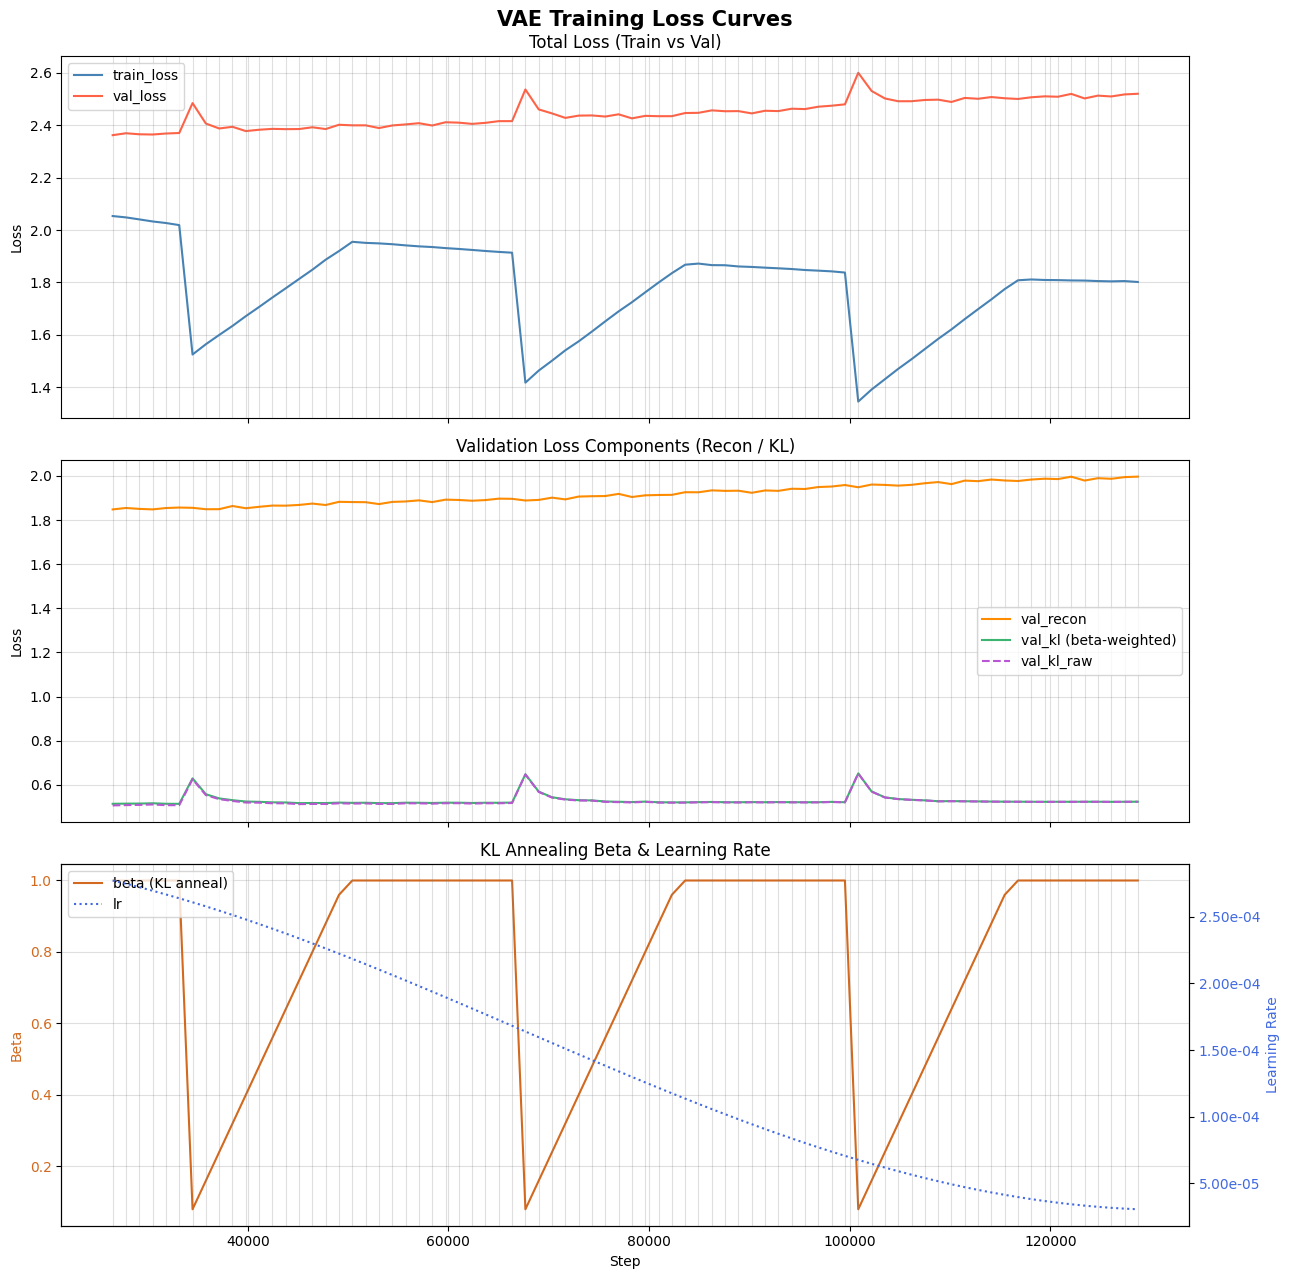

绘图完成！


In [8]:
x = df_loss['step']

fig, axes = plt.subplots(3, 1, figsize=(13, 13), sharex=True)
fig.suptitle('VAE Training Loss Curves', fontsize=15, fontweight='bold')

# ---- 子图1: 总损失 ----
ax1 = axes[0]
if 'train_loss' in df_loss.columns:
    ax1.plot(x, df_loss['train_loss'], label='train_loss', color='steelblue', linewidth=1.5)
if 'val_loss' in df_loss.columns:
    ax1.plot(x, df_loss['val_loss'], label='val_loss', color='tomato', linewidth=1.5)
ax1.set_ylabel('Loss')
ax1.set_title('Total Loss (Train vs Val)')
ax1.legend()
ax1.grid(True, alpha=0.4)

# ---- 子图2: 验证集分项损失 ----
ax2 = axes[1]
if 'val_recon' in df_loss.columns:
    ax2.plot(x, df_loss['val_recon'], label='val_recon', color='darkorange', linewidth=1.5)
if 'val_kl' in df_loss.columns:
    ax2.plot(x, df_loss['val_kl'], label='val_kl (beta-weighted)', color='mediumseagreen', linewidth=1.5)
if 'val_kl_raw' in df_loss.columns:
    ax2.plot(x, df_loss['val_kl_raw'], label='val_kl_raw', color='mediumorchid',
             linewidth=1.5, linestyle='--')
ax2.set_ylabel('Loss')
ax2.set_title('Validation Loss Components (Recon / KL)')
ax2.legend()
ax2.grid(True, alpha=0.4)

# ---- 子图3: beta 和 lr ----
ax3 = axes[2]
color_beta = 'chocolate'
color_lr   = 'royalblue'
has_beta = 'train_beta' in df_loss.columns
has_lr   = 'lr' in df_loss.columns

if has_beta:
    ax3.plot(x, df_loss['train_beta'], label='beta (KL anneal)', color=color_beta, linewidth=1.5)
    ax3.set_ylabel('Beta', color=color_beta)
    ax3.tick_params(axis='y', labelcolor=color_beta)

if has_lr:
    ax3_lr = ax3.twinx()
    ax3_lr.plot(x, df_loss['lr'], label='lr', color=color_lr, linewidth=1.5, linestyle=':')
    ax3_lr.set_ylabel('Learning Rate', color=color_lr)
    ax3_lr.tick_params(axis='y', labelcolor=color_lr)
    ax3_lr.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2e'))
    # 合并图例
    lines1, labels1 = ax3.get_legend_handles_labels()
    lines2, labels2 = ax3_lr.get_legend_handles_labels()
    ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
elif has_beta:
    ax3.legend()

ax3.set_xlabel('Step')
ax3.set_title('KL Annealing Beta & Learning Rate')
ax3.grid(True, alpha=0.4)

# 在x轴上方标注epoch（如果有）
if 'epoch' in df_loss.columns:
    # 每个epoch的第一个step
    epoch_steps = df_loss.drop_duplicates(subset='epoch', keep='first')[['epoch','step']]
    for _, row in epoch_steps.iterrows():
        axes[0].axvline(x=row['step'], color='gray', alpha=0.25, linewidth=0.8)
        axes[1].axvline(x=row['step'], color='gray', alpha=0.25, linewidth=0.8)
        axes[2].axvline(x=row['step'], color='gray', alpha=0.25, linewidth=0.8)

plt.tight_layout()
plt.show()
print("绘图完成！")

## 5. 保存和展示损失曲线图像

本节将损失曲线保存为图片文件，并在notebook中展示。

In [ ]:
# 保存损失曲线为图片
img_path = 'vae_loss_curve.png'

x = df_loss['step']
fig, axes = plt.subplots(3, 1, figsize=(13, 13), sharex=True)
fig.suptitle('VAE Training Loss Curves', fontsize=15, fontweight='bold')

ax1 = axes[0]
if 'train_loss' in df_loss.columns:
    ax1.plot(x, df_loss['train_loss'], label='train_loss', color='steelblue', linewidth=1.5)
if 'val_loss' in df_loss.columns:
    ax1.plot(x, df_loss['val_loss'], label='val_loss', color='tomato', linewidth=1.5)
ax1.set_ylabel('Loss')
ax1.set_title('Total Loss (Train vs Val)')
ax1.legend()
ax1.grid(True, alpha=0.4)

ax2 = axes[1]
if 'val_recon' in df_loss.columns:
    ax2.plot(x, df_loss['val_recon'], label='val_recon', color='darkorange', linewidth=1.5)
if 'val_kl' in df_loss.columns:
    ax2.plot(x, df_loss['val_kl'], label='val_kl (beta-weighted)', color='mediumseagreen', linewidth=1.5)
if 'val_kl_raw' in df_loss.columns:
    ax2.plot(x, df_loss['val_kl_raw'], label='val_kl_raw', color='mediumorchid',
             linewidth=1.5, linestyle='--')
ax2.set_ylabel('Loss')
ax2.set_title('Validation Loss Components (Recon / KL)')
ax2.legend()
ax2.grid(True, alpha=0.4)

ax3 = axes[2]
color_beta = 'chocolate'
color_lr   = 'royalblue'
has_beta = 'train_beta' in df_loss.columns
has_lr   = 'lr' in df_loss.columns

if has_beta:
    ax3.plot(x, df_loss['train_beta'], label='beta (KL anneal)', color=color_beta, linewidth=1.5)
    ax3.set_ylabel('Beta', color=color_beta)
    ax3.tick_params(axis='y', labelcolor=color_beta)

if has_lr:
    ax3_lr = ax3.twinx()
    ax3_lr.plot(x, df_loss['lr'], label='lr', color=color_lr, linewidth=1.5, linestyle=':')
    ax3_lr.set_ylabel('Learning Rate', color=color_lr)
    ax3_lr.tick_params(axis='y', labelcolor=color_lr)
    ax3_lr.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2e'))
    lines1, labels1 = ax3.get_legend_handles_labels()
    lines2, labels2 = ax3_lr.get_legend_handles_labels()
    ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
elif has_beta:
    ax3.legend()

ax3.set_xlabel('Step')
ax3.set_title('KL Annealing Beta & Learning Rate')
ax3.grid(True, alpha=0.4)

if 'epoch' in df_loss.columns:
    epoch_steps = df_loss.drop_duplicates(subset='epoch', keep='first')[['epoch','step']]
    for _, row in epoch_steps.iterrows():
        for ax in axes:
            ax.axvline(x=row['step'], color='gray', alpha=0.25, linewidth=0.8)

plt.tight_layout()
plt.savefig(img_path, dpi=150)
print(f"损失曲线已保存为: {img_path}")

# 展示图片
from IPython.display import Image, display
display(Image(filename=img_path))